In [1]:
# import some libraries:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
from numpy import *

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/online-retail-file/Copy of Online Retail.xlsx
/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [3]:
# Making dataframe:
import pandas as pd
df = pd.read_excel("../input/online-retail-file/Copy of Online Retail.xlsx")

In [4]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


# Drop the unused columns

In [5]:
# drop the unused columns:
df.drop(['StockCode', 'Description', 'Country'], inplace=True, axis=1)
df.head()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536365,6,2010-12-01 08:26:00,2.55,17850.0
1,536365,6,2010-12-01 08:26:00,3.39,17850.0
2,536365,8,2010-12-01 08:26:00,2.75,17850.0
3,536365,6,2010-12-01 08:26:00,3.39,17850.0
4,536365,6,2010-12-01 08:26:00,3.39,17850.0


In [6]:
# Rename the columns name:
df.rename(columns={'InvoiceNo':'OrderID', 'InvoiceDate':'Order_Date', 'UnitPrice':'Sales_Price'}, inplace=True)
df.head()

,OrderID,Quantity,Order_Date,Sales_Price,CustomerID
0,536365,6,2010-12-01 08:26:00,2.55,17850.0
1,536365,6,2010-12-01 08:26:00,3.39,17850.0
2,536365,8,2010-12-01 08:26:00,2.75,17850.0
3,536365,6,2010-12-01 08:26:00,3.39,17850.0
4,536365,6,2010-12-01 08:26:00,3.39,17850.0


In [7]:
#Arrenging by order:
first_column = df.pop('Order_Date')
df.insert(1, 'Order_Date', first_column)
df

,OrderID,Order_Date,Quantity,Sales_Price,CustomerID
0,536365,2010-12-01 08:26:00,6,2.55,17850.0
1,536365,2010-12-01 08:26:00,6,3.39,17850.0
2,536365,2010-12-01 08:26:00,8,2.75,17850.0
3,536365,2010-12-01 08:26:00,6,3.39,17850.0
4,536365,2010-12-01 08:26:00,6,3.39,17850.0
...,...,...,...,...,...
541904,581587,2011-12-09 12:50:00,12,0.85,12680.0
541905,581587,2011-12-09 12:50:00,6,2.10,12680.0
541906,581587,2011-12-09 12:50:00,4,4.15,12680.0
541907,581587,2011-12-09 12:50:00,4,4.15,12680.0


In [8]:
#Arrenging by order:
first_column = df.pop('CustomerID')
df.insert(2, 'CustomerID', first_column)
df

,OrderID,Order_Date,CustomerID,Quantity,Sales_Price
0,536365,2010-12-01 08:26:00,17850.0,6,2.55
1,536365,2010-12-01 08:26:00,17850.0,6,3.39
2,536365,2010-12-01 08:26:00,17850.0,8,2.75
3,536365,2010-12-01 08:26:00,17850.0,6,3.39
4,536365,2010-12-01 08:26:00,17850.0,6,3.39
...,...,...,...,...,...
541904,581587,2011-12-09 12:50:00,12680.0,12,0.85
541905,581587,2011-12-09 12:50:00,12680.0,6,2.10
541906,581587,2011-12-09 12:50:00,12680.0,4,4.15
541907,581587,2011-12-09 12:50:00,12680.0,4,4.15


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   OrderID      541909 non-null  object        
 1   Order_Date   541909 non-null  datetime64[ns]
 2   CustomerID   406829 non-null  float64       
 3   Quantity     541909 non-null  int64         
 4   Sales_Price  541909 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 20.7+ MB


In [10]:
df[df.isnull().any(axis=1)]

,OrderID,Order_Date,CustomerID,Quantity,Sales_Price
622,536414,2010-12-01 11:52:00,NaN,56,0.00
1443,536544,2010-12-01 14:32:00,NaN,1,2.51
1444,536544,2010-12-01 14:32:00,NaN,2,2.51
1445,536544,2010-12-01 14:32:00,NaN,4,0.85
1446,536544,2010-12-01 14:32:00,NaN,2,1.66
...,...,...,...,...,...
541536,581498,2011-12-09 10:26:00,NaN,5,4.13
541537,581498,2011-12-09 10:26:00,NaN,4,4.13
541538,581498,2011-12-09 10:26:00,NaN,1,4.96
541539,581498,2011-12-09 10:26:00,NaN,1,10.79


In [11]:
df.dropna(subset=['CustomerID'], inplace=True)
df

,OrderID,Order_Date,CustomerID,Quantity,Sales_Price
0,536365,2010-12-01 08:26:00,17850.0,6,2.55
1,536365,2010-12-01 08:26:00,17850.0,6,3.39
2,536365,2010-12-01 08:26:00,17850.0,8,2.75
3,536365,2010-12-01 08:26:00,17850.0,6,3.39
4,536365,2010-12-01 08:26:00,17850.0,6,3.39
...,...,...,...,...,...
541904,581587,2011-12-09 12:50:00,12680.0,12,0.85
541905,581587,2011-12-09 12:50:00,12680.0,6,2.10
541906,581587,2011-12-09 12:50:00,12680.0,4,4.15
541907,581587,2011-12-09 12:50:00,12680.0,4,4.15


# Dropping negative values

In [12]:
df.drop(df[df['Quantity'] <=0.0].index, inplace=True)
df

,OrderID,Order_Date,CustomerID,Quantity,Sales_Price
0,536365,2010-12-01 08:26:00,17850.0,6,2.55
1,536365,2010-12-01 08:26:00,17850.0,6,3.39
2,536365,2010-12-01 08:26:00,17850.0,8,2.75
3,536365,2010-12-01 08:26:00,17850.0,6,3.39
4,536365,2010-12-01 08:26:00,17850.0,6,3.39
...,...,...,...,...,...
541904,581587,2011-12-09 12:50:00,12680.0,12,0.85
541905,581587,2011-12-09 12:50:00,12680.0,6,2.10
541906,581587,2011-12-09 12:50:00,12680.0,4,4.15
541907,581587,2011-12-09 12:50:00,12680.0,4,4.15


In [13]:
df.drop(df[df['Sales_Price'] <=0.0].index, inplace=True)
df

,OrderID,Order_Date,CustomerID,Quantity,Sales_Price
0,536365,2010-12-01 08:26:00,17850.0,6,2.55
1,536365,2010-12-01 08:26:00,17850.0,6,3.39
2,536365,2010-12-01 08:26:00,17850.0,8,2.75
3,536365,2010-12-01 08:26:00,17850.0,6,3.39
4,536365,2010-12-01 08:26:00,17850.0,6,3.39
...,...,...,...,...,...
541904,581587,2011-12-09 12:50:00,12680.0,12,0.85
541905,581587,2011-12-09 12:50:00,12680.0,6,2.10
541906,581587,2011-12-09 12:50:00,12680.0,4,4.15
541907,581587,2011-12-09 12:50:00,12680.0,4,4.15


# Finding total sales price for each customer

In [14]:
df["Total_Sales_Price"]= df["Quantity"]*df["Sales_Price"]
df

,OrderID,Order_Date,CustomerID,Quantity,Sales_Price,Total_Sales_Price
0,536365,2010-12-01 08:26:00,17850.0,6,2.55,15.30
1,536365,2010-12-01 08:26:00,17850.0,6,3.39,20.34
2,536365,2010-12-01 08:26:00,17850.0,8,2.75,22.00
3,536365,2010-12-01 08:26:00,17850.0,6,3.39,20.34
4,536365,2010-12-01 08:26:00,17850.0,6,3.39,20.34
...,...,...,...,...,...,...
541904,581587,2011-12-09 12:50:00,12680.0,12,0.85,10.20
541905,581587,2011-12-09 12:50:00,12680.0,6,2.10,12.60
541906,581587,2011-12-09 12:50:00,12680.0,4,4.15,16.60
541907,581587,2011-12-09 12:50:00,12680.0,4,4.15,16.60


In [15]:
df

,OrderID,Order_Date,CustomerID,Quantity,Sales_Price,Total_Sales_Price
0,536365,2010-12-01 08:26:00,17850.0,6,2.55,15.30
1,536365,2010-12-01 08:26:00,17850.0,6,3.39,20.34
2,536365,2010-12-01 08:26:00,17850.0,8,2.75,22.00
3,536365,2010-12-01 08:26:00,17850.0,6,3.39,20.34
4,536365,2010-12-01 08:26:00,17850.0,6,3.39,20.34
...,...,...,...,...,...,...
541904,581587,2011-12-09 12:50:00,12680.0,12,0.85,10.20
541905,581587,2011-12-09 12:50:00,12680.0,6,2.10,12.60
541906,581587,2011-12-09 12:50:00,12680.0,4,4.15,16.60
541907,581587,2011-12-09 12:50:00,12680.0,4,4.15,16.60


# Change the date-time formate in dd-mm-yy and deleting hrs-ss

In [16]:
#changing into datetimeforat
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [17]:
#removing hrs:second from date
df['Order_Date'] = df['Order_Date'].dt.strftime('%d/%m/%Y')
df.head()

,OrderID,Order_Date,CustomerID,Quantity,Sales_Price,Total_Sales_Price
0,536365,01/12/2010,17850.0,6,2.55,15.30
1,536365,01/12/2010,17850.0,6,3.39,20.34
2,536365,01/12/2010,17850.0,8,2.75,22.00
3,536365,01/12/2010,17850.0,6,3.39,20.34
4,536365,01/12/2010,17850.0,6,3.39,20.34


# Copy new CSV file

In [18]:
df.to_csv("new_online_retail")

# **used data.world For SQL**

# **SQL Query for RFM Analysis**

In [19]:
#sql query for rfm analysis
'''WITH dataset AS (
    SELECT customerid,
    MAX(order_date) as last_order_date,
    COUNT(orderid) as count_order,
    SUM(new_online_retail.sales_price) as avg_amount
        from new_online_retail
        group by customerid
),

order_s as (
    SELECT customerid,
    NTILE(3) OVER (ORDER BY last_order_date) as rfm_recency,
    NTILE(3) OVER (ORDER BY count_order) as rfm_frequency,
    NTILE(3) OVER (ORDER BY avg_amount) as rfm_monetary
    FROM dataset
)
select customerid, rfm_recency*100 + rfm_frequency*10 + rfm_monetary as rfm_combined 
from order_s
ORDER BY customerid ASC'''

'WITH dataset AS (\n    SELECT customerid,\n    MAX(order_date) as last_order_date,\n    COUNT(orderid) as count_order,\n    SUM(new_online_retail.sales_price) as avg_amount\n        from new_online_retail\n        group by customerid\n),\n\norder_s as (\n    SELECT customerid,\n    NTILE(3) OVER (ORDER BY last_order_date) as rfm_recency,\n    NTILE(3) OVER (ORDER BY count_order) as rfm_frequency,\n    NTILE(3) OVER (ORDER BY avg_amount) as rfm_monetary\n    FROM dataset\n)\nselect customerid, rfm_recency*100 + rfm_frequency*10 + rfm_monetary as rfm_combined \nfrom order_s\nORDER BY customerid ASC'

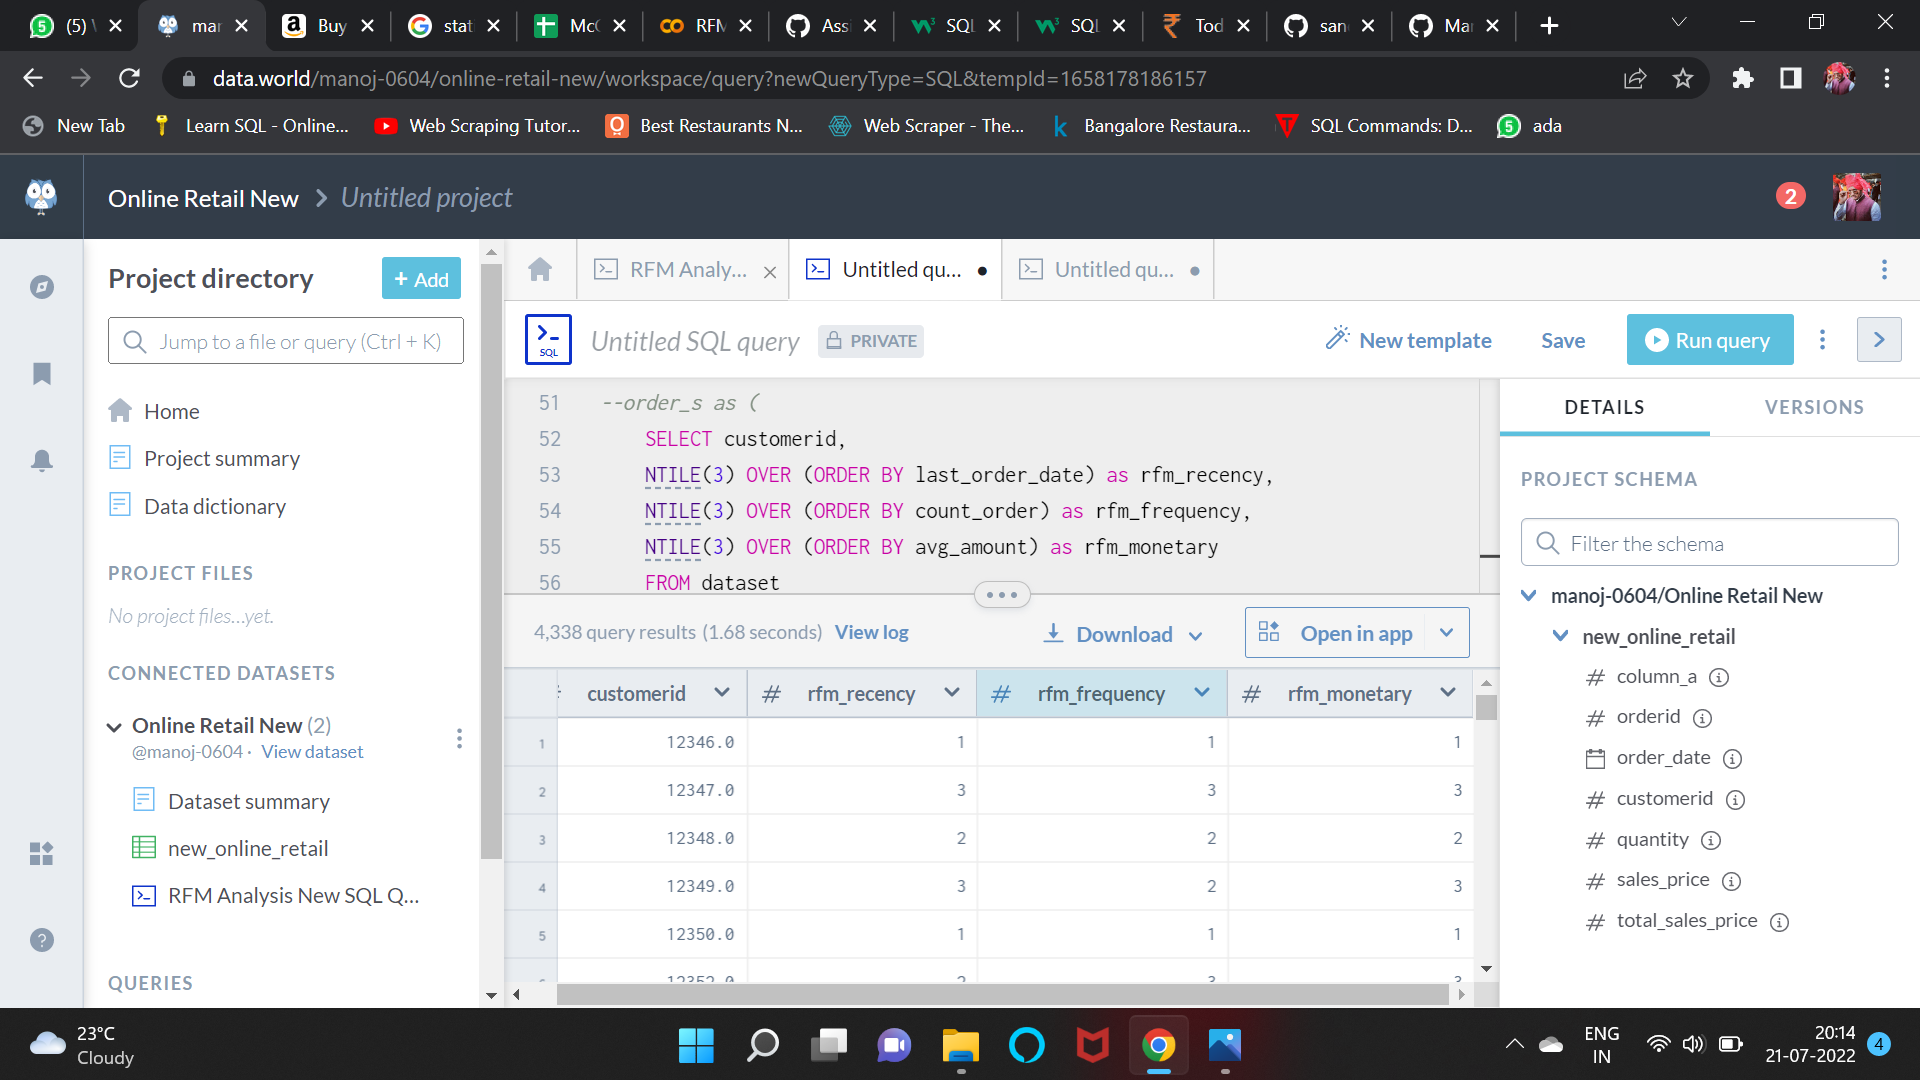

# **SQL Query for RFM Analysis**

In [20]:
#different querry for rfm analysis
'''SELECT * FROM new_online_retail LIMIT 10000


/** step 2. Exam the dataset **/
SELECT 
    orderid,
    order_date,
    customerid,
    sales_price,
    COUNT(orderid) OVER(PARTITION BY customerid, orderid)

FROM new_online_retail


/** step 3. summerise the dataset **/
Order_Summary as (
    
    SELECT
        orderid, order_date, customerid,
        SUM(sales_price)
    FROM new_online_retail
    GROUP BY orderid, order_date, customerid


/** step 4. put together the RFM report **/
SELECT
orderid, order_date, customerid,
(SELECT MIN(order_date) FROM new_online_retail) as min_order_date,
(SELECT MAX(order_date) FROM new_online_retail WHERE customerid = customerid) as max_customer_order_date,
DATE_DIFF ((SELECT MIN(order_date) FROM new_online_retail WHERE customerid = customerid),(SELECT MAX(order_date) FROM new_online_retail), 'DAY' ) as Recency,
COUNT(orderid) as Frequency,
SUM(sales_price) as Monetary
NTILE(3) OVER (ORDER BY DATE_DIFF ((SELECT MIN(order_date) FROM new_online_retail WHERE customerid = customerid),(SELECT MAX(order_date) FROM new_online_retail), 'DAY') DESC) as R,
NTILE(3) OVER (ORDER BY COUNT(orderid) ASC) F,
NTILE(3) OVER (ORDER BY SUM(sales_price) ASC) M

FROM new_online_retail
GROUP BY customerid
ORDER BY 1, 3 DESC'''

"SELECT * FROM new_online_retail LIMIT 10000\n\n\n/** step 2. Exam the dataset **/\nSELECT \n    orderid,\n    order_date,\n    customerid,\n    sales_price,\n    COUNT(orderid) OVER(PARTITION BY customerid, orderid)\n\nFROM new_online_retail\n\n\n/** step 3. summerise the dataset **/\nOrder_Summary as (\n    \n    SELECT\n        orderid, order_date, customerid,\n        SUM(sales_price)\n    FROM new_online_retail\n    GROUP BY orderid, order_date, customerid\n\n\n/** step 4. put together the RFM report **/\nSELECT\norderid, order_date, customerid,\n(SELECT MIN(order_date) FROM new_online_retail) as min_order_date,\n(SELECT MAX(order_date) FROM new_online_retail WHERE customerid = customerid) as max_customer_order_date,\nDATE_DIFF ((SELECT MIN(order_date) FROM new_online_retail WHERE customerid = customerid),(SELECT MAX(order_date) FROM new_online_retail), 'DAY' ) as Recency,\nCOUNT(orderid) as Frequency,\nSUM(sales_price) as Monetary\nNTILE(3) OVER (ORDER BY DATE_DIFF ((SELECT MIN(o

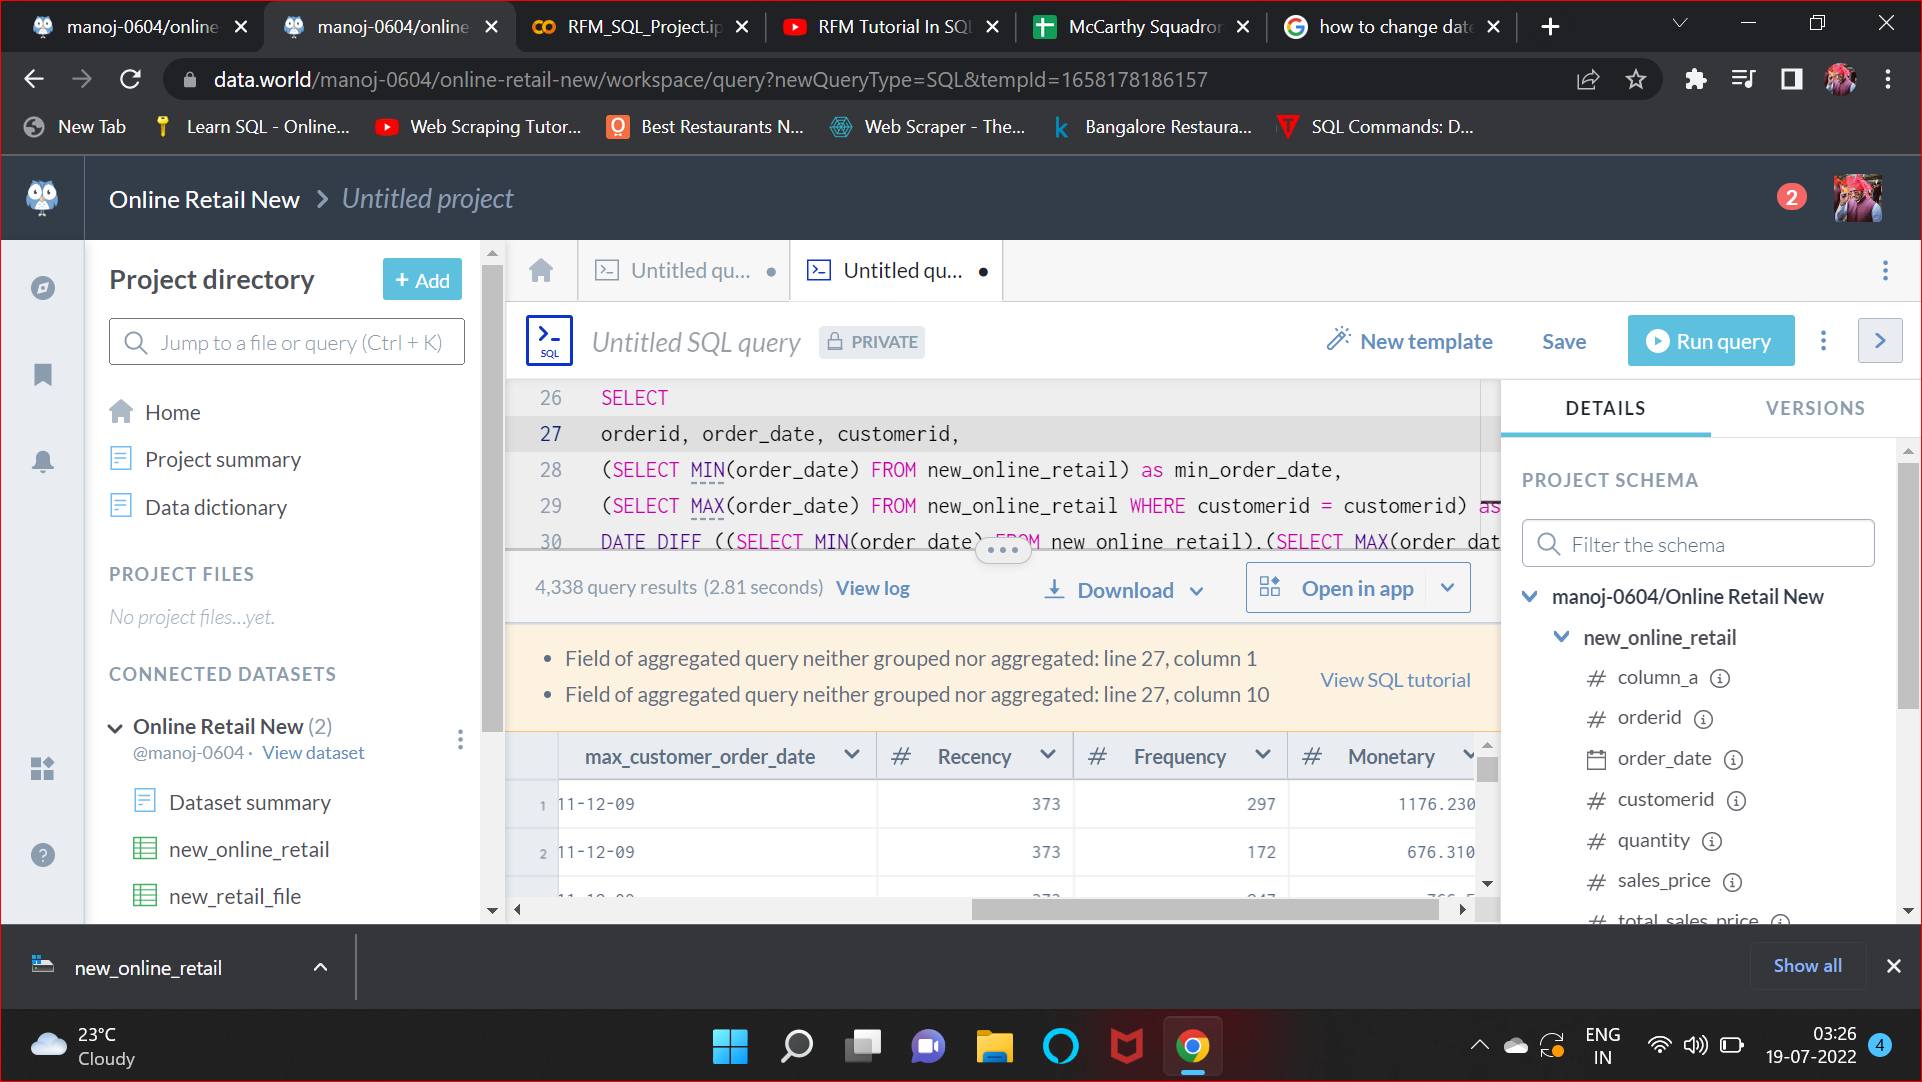